In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Chargement des données
df = pd.read_csv("cve_anssi_enriched.csv")

# Nettoyage rapide
df = df.dropna(subset=["cvss", "epss"])
df = df[df["cvss"] != "Non disponible"]
df = df[df["epss"] != "Non disponible"]
df["cvss"] = df["cvss"].astype(float)
df["epss"] = df["epss"].astype(float)

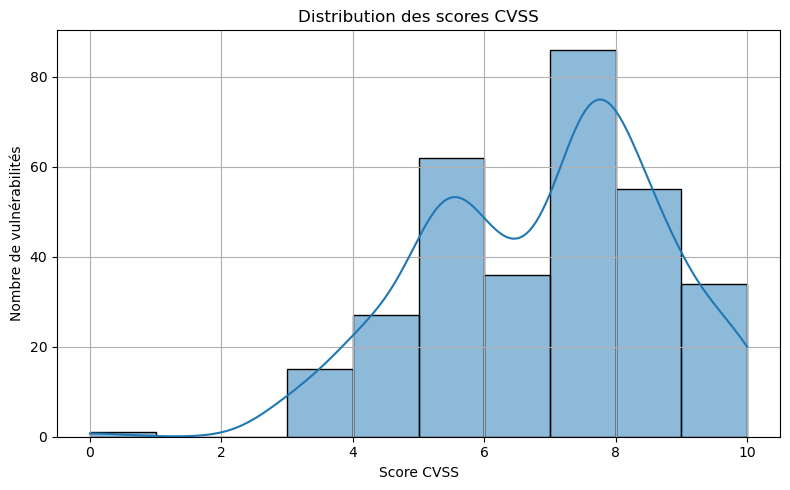

In [3]:
# Histogramme des scores CVSS
plt.figure(figsize=(8, 5))
sns.histplot(df["cvss"], bins=10, kde=True)
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de vulnérabilités")
plt.grid(True)
plt.tight_layout()
plt.savefig("cvss_distribution.png")
plt.show()

C:\Users\antoi\AppData\Local\Temp\ipykernel_15416\1343389248.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  epss_means = df.groupby('cvss_bin')['epss'].mean().reset_index()


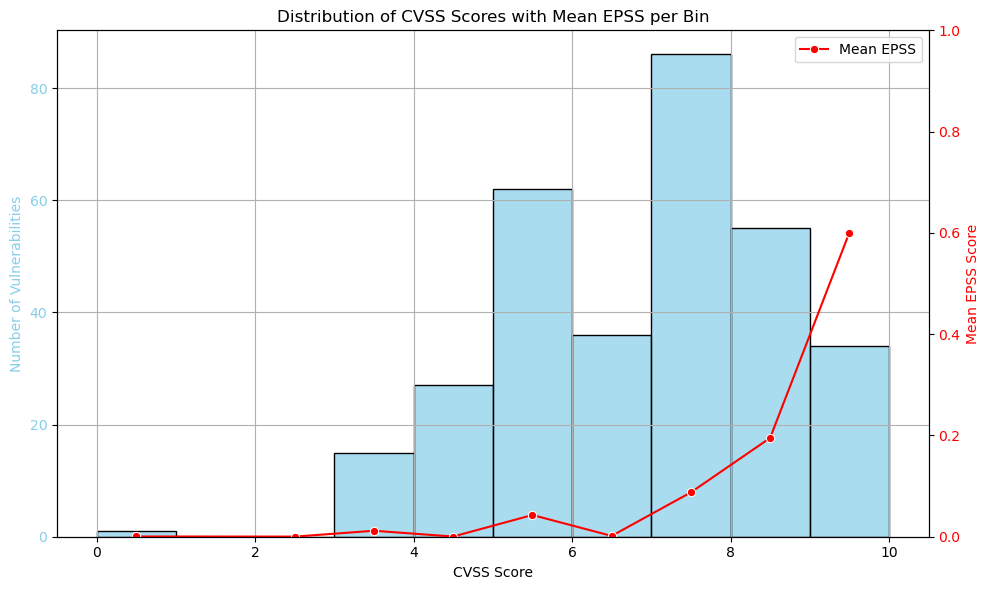

In [42]:
df['cvss_bin'] = pd.cut(df['cvss'], bins=10)

# Calculate mean EPSS for each CVSS bin
epss_means = df.groupby('cvss_bin')['epss'].mean().reset_index()
epss_means['cvss_mid'] = epss_means['cvss_bin'].apply(lambda x: x.mid)

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Histogram of CVSS scores (left axis)
sns.histplot(df['cvss'], bins=10, kde=False, ax=ax1, color='skyblue', alpha=0.7)
ax1.set_xlabel('CVSS Score')
ax1.set_ylabel('Number of Vulnerabilities', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.grid(True)

# Line plot of mean EPSS (right axis)
ax2 = ax1.twinx()
sns.lineplot(x='cvss_mid', y='epss', data=epss_means, 
             ax=ax2, color='red', marker='o', label='Mean EPSS')
ax2.set_ylabel('Mean EPSS Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1)  # EPSS ranges from 0 to 1

# Title and legend
plt.title('Distribution of CVSS Scores with Mean EPSS per Bin')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig("cvss_distribution_with_epss.png")
plt.show()

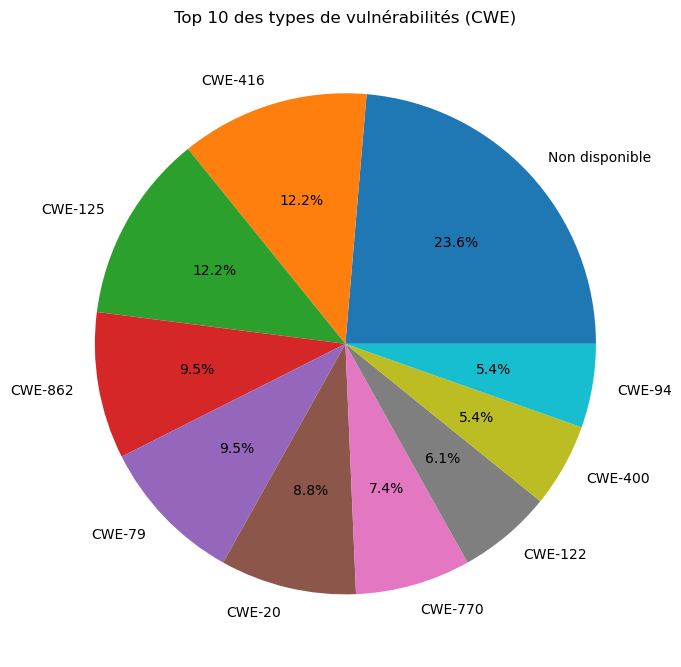

In [18]:
# Diagramme circulaire des types CWE
top_cwe = df["cwe"].value_counts().head(10)
plt.figure(figsize=(7, 7))
top_cwe.plot.pie(autopct="%1.1f%%")
plt.title("Top 10 des types de vulnérabilités (CWE)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("cwe_pie.png")
plt.show()

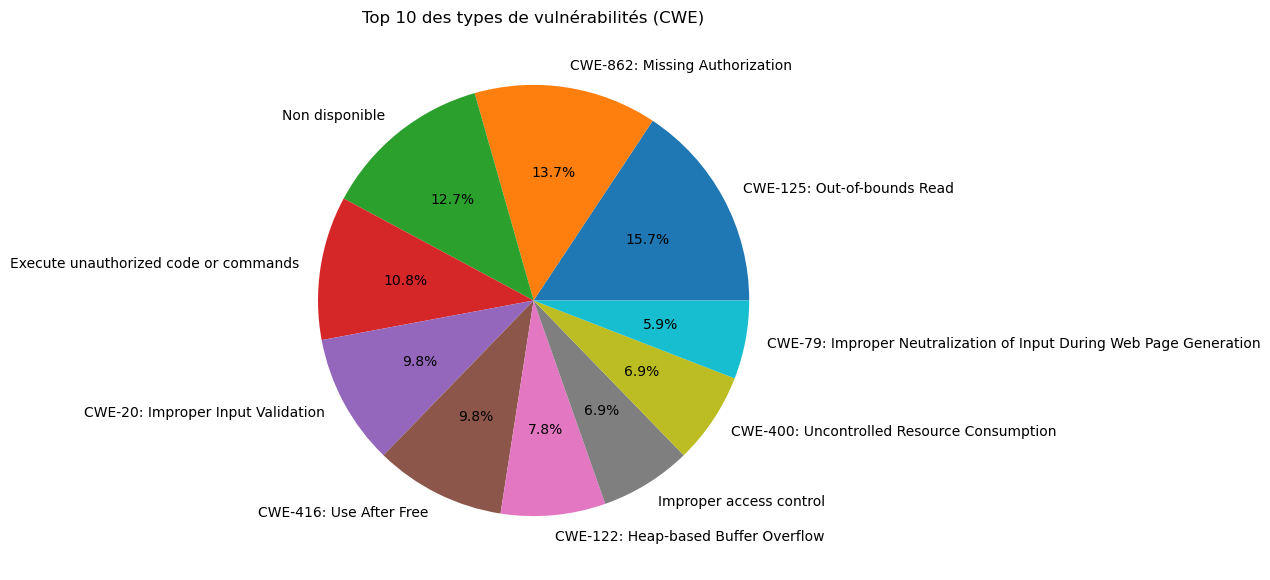

In [17]:
# Diagramme circulaire des types CWE
top_cwe = df["cwe_desc"].value_counts().head(10)
plt.figure(figsize=(7, 7))
top_cwe.plot.pie(autopct="%1.1f%%")
plt.title("Top 10 des types de vulnérabilités (CWE)")
plt.ylabel("")

plt.savefig("cwe_desc_pie.png")
plt.show()

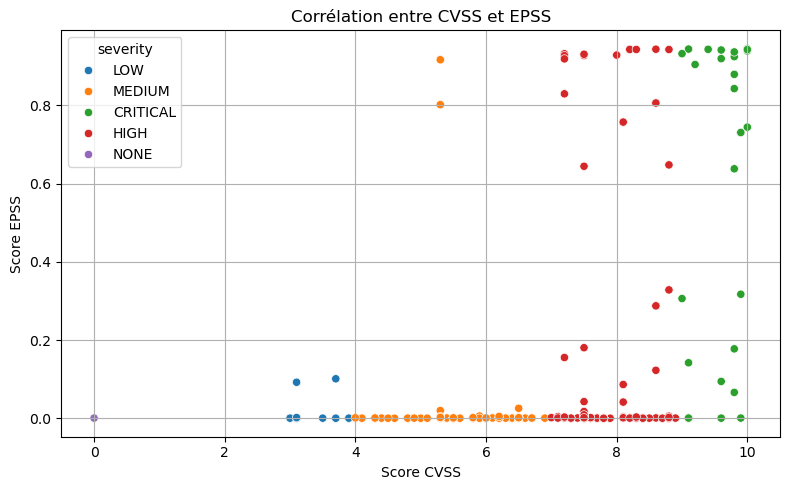

In [5]:
# Nuage de points CVSS vs EPSS
plt.figure(figsize=(8, 5))
sns.scatterplot(x="cvss", y="epss", data=df, hue="severity")
plt.title("Corrélation entre CVSS et EPSS")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.grid(True)
plt.tight_layout()
plt.savefig("scatter_cvss_epss.png")
plt.show()

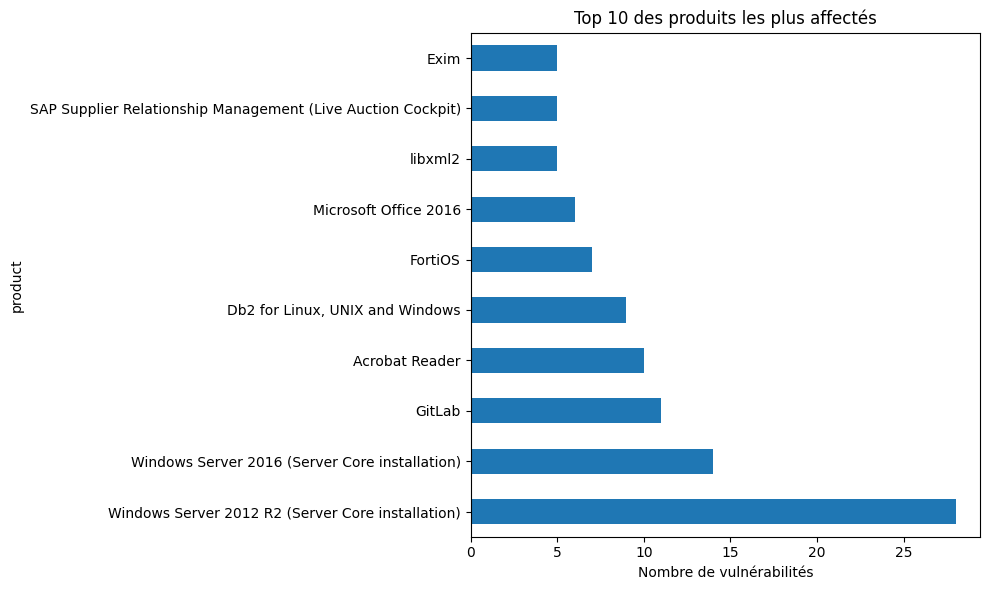

In [10]:
# Produits les plus affectés
plt.figure(figsize=(10, 6))
df["product"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 des produits les plus affectés")
plt.xlabel("Nombre de vulnérabilités")
plt.tight_layout()
plt.savefig("top_products.png")
plt.show()

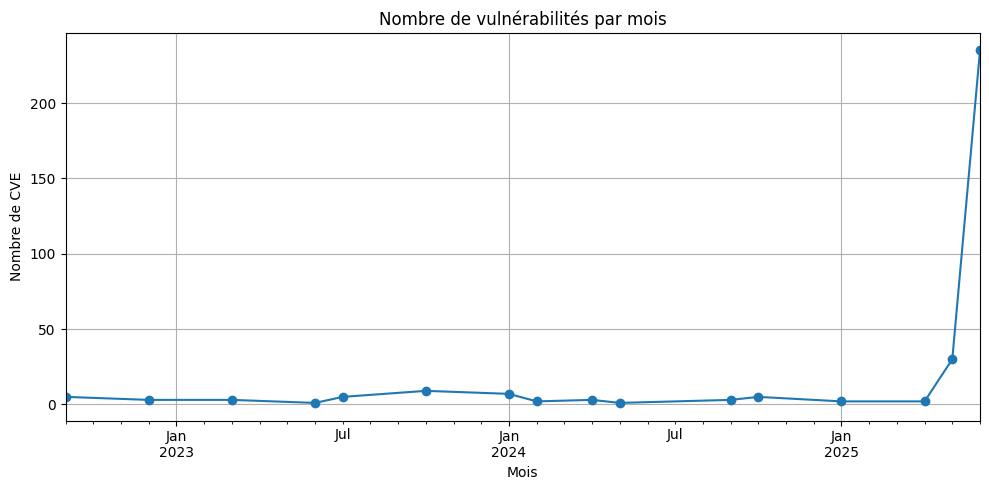

In [11]:
# Évolution temporelle
df["date"] = pd.to_datetime(df["date"])
df_by_month = df.groupby(df["date"].dt.to_period("M")).size()
df_by_month.plot(kind="line", marker="o", figsize=(10, 5))
plt.title("Nombre de vulnérabilités par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de CVE")
plt.grid(True)bn
plt.tight_layout()
plt.savefig("timeline.png")
plt.show()

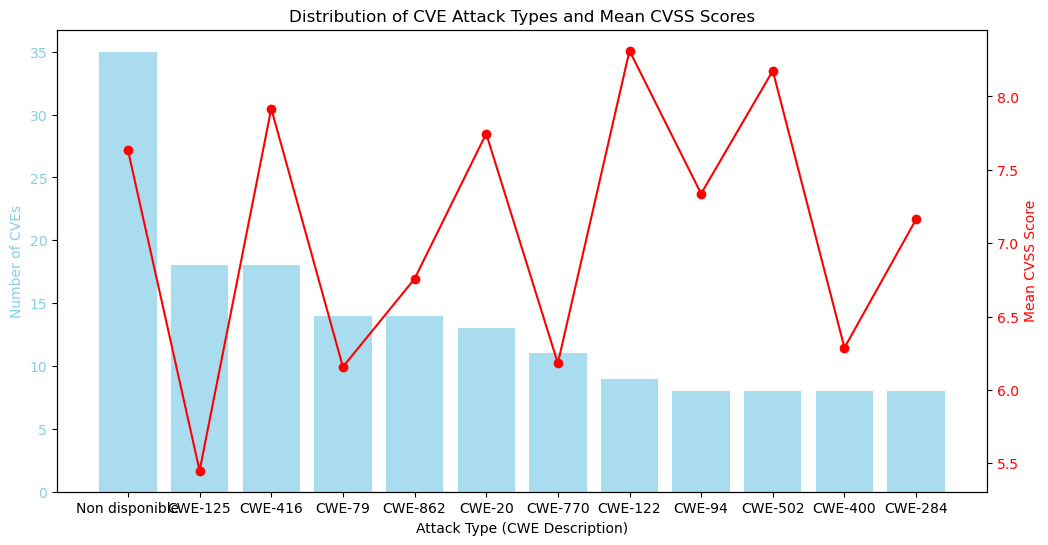

In [41]:

#rapport entre type d'attaques et sévérité
attack_stats = df.groupby('cwe').agg(
    count=('cve', 'size'),
    mean_cvss=('cvss', 'mean')
).sort_values(by='count', ascending=False).reset_index().head(12)
fig, ax1 = plt.subplots(figsize=(12, 6))
# Bar plot (frequency of attack types)
ax1.bar(attack_stats['cwe'], attack_stats['count'], color='skyblue', alpha=0.7, label='Number of CVEs')
ax1.set_xlabel('Attack Type (CWE Description)')
ax1.set_ylabel('Number of CVEs', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Line plot (mean CVSS)
ax2 = ax1.twinx()
ax2.plot(attack_stats['cwe'], attack_stats['mean_cvss'], color='red', marker='o', label='Mean CVSS')
ax2.set_ylabel('Mean CVSS Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and legend
plt.title('Distribution of CVE Attack Types and Mean CVSS Scores')
plt.savefig("mean_cvss_per_cve.png")
plt.show()

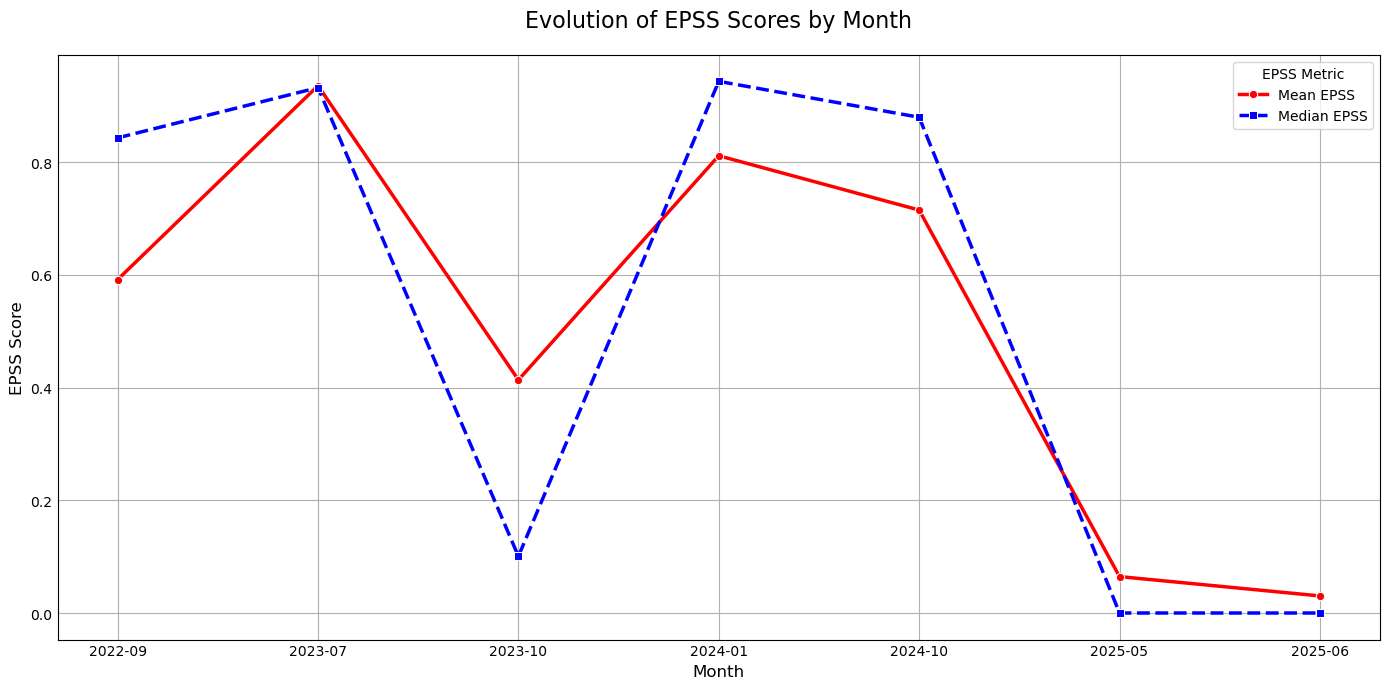

In [51]:
#moyenne epss par mois (proba/frequence d'attaque)
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')
df['epss'] = pd.to_numeric(df['epss'], errors='coerce')
monthly_stats = df.groupby('year_month')['epss'].agg(['mean', 'median', 'count']).reset_index()
monthly_stats['year_month'] = monthly_stats['year_month'].astype(str)
monthly_stats = monthly_stats[monthly_stats['count'] >= 4]
plt.figure(figsize=(14, 7))
sns.lineplot(x='year_month', y='mean', data=monthly_stats, 
             marker='o', color='red', linewidth=2.5, label='Mean EPSS')
sns.lineplot(x='year_month', y='median', data=monthly_stats,
             marker='s', color='blue', linewidth=2.5, linestyle='--', label='Median EPSS')
plt.title('Evolution of EPSS Scores by Month', fontsize=16, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('EPSS Score', fontsize=12)
plt.legend(title='EPSS Metric')
plt.tight_layout()
plt.savefig('epss_trend_by_month.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\antoi\AppData\Local\Temp\ipykernel_15416\78594217.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=product_stats.index, y='mean', data=product_stats,
C:\Users\antoi\AppData\Local\Temp\ipykernel_15416\78594217.py:14: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  points = sns.pointplot(x=product_stats.index, y='max', data=product_stats,


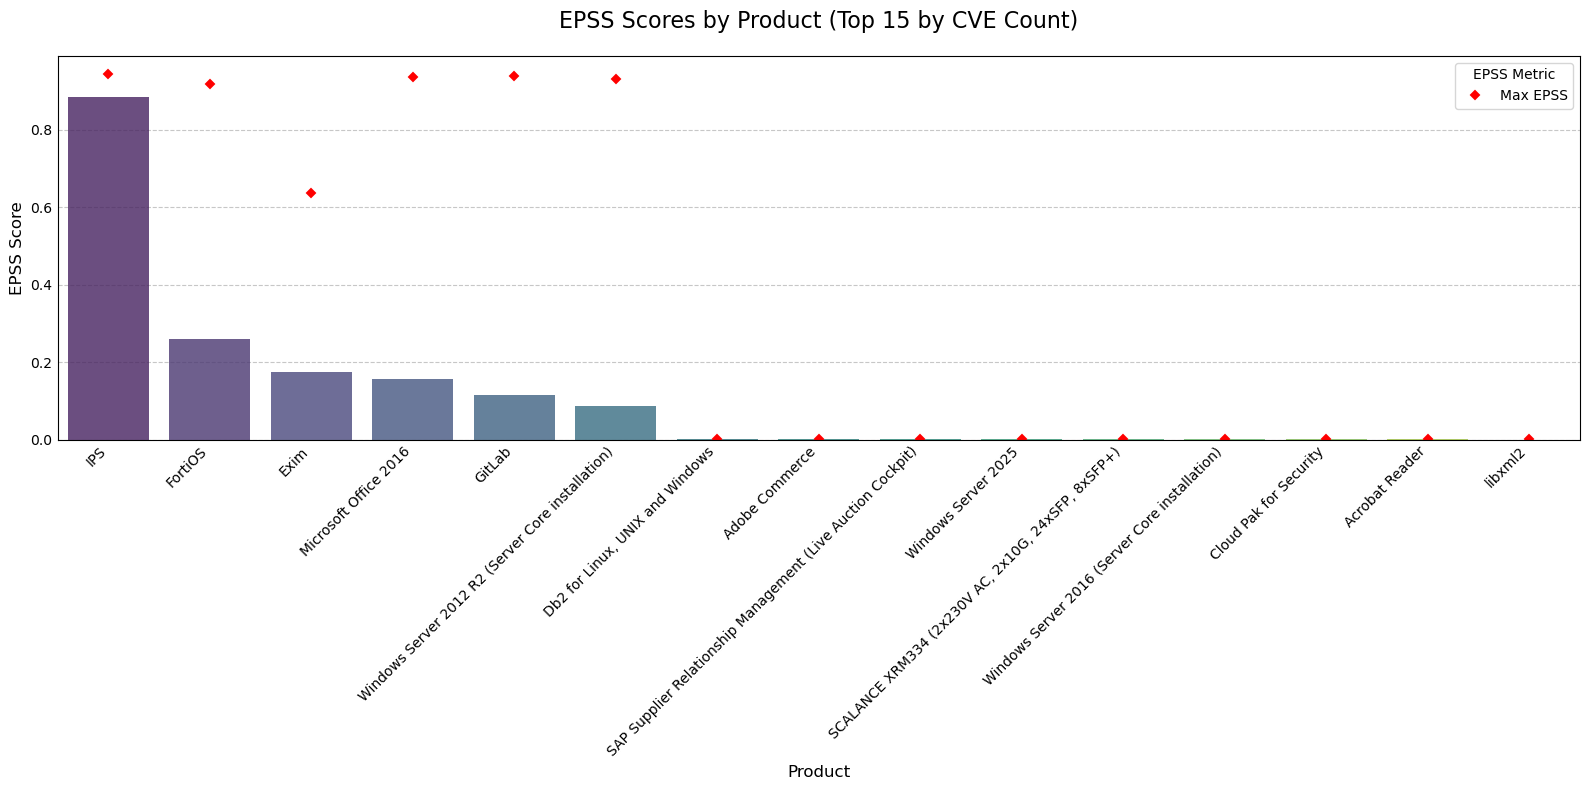